In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
plt.style.use('../../../foresight.mplstyle')


/headnode2/bhar9988/code/DDC/WRCircuit.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = src.models.FNS
fixed_params = {
    'N_e': 1000,
    'J_e': 0.0008,
    'n_ext': 100,
    # 'K_ee': 36,
    'K_ei': 56,
    'K_ie': 44,
    'K_ii': 78,
}
monitors = ['E.spike', 'E.V', 'E.input']
stats = {"rate": src.stats.firing_rate,
         "susceptibility": src.stats.susceptibility(10),
         "spike_spectrum": src.stats.spike_spectrum(10),
         "temporal_average": src.stats.temporal_average,
         "grand_distribution": src.stats.grand_distribution(1000),
         }
duration = 1000.0
transient = 200.0

run = src.stats.create_run(model, fixed_params, monitors, duration, transient)
stats_run = src.stats.create_stats_run(run, stats)

params = {
    'nu': np.array([8.0, 10.0, 8.0, 10.0]),
    'delta': np.array([4.0, 4.0, 8.0, 10.0]),
    'key': np.array(jax.random.split(jax.random.PRNGKey(42), 4)),
    'K_ee': (100, 200, 100, 200)}

In [3]:
# axes_names = ('nu', 'delta')
# in_axes = ({k: 0 if k in axes_names else None for k in params.keys()},)
# jax.vmap(lambda input_dict: stats_run(**params), in_axes=in_axes)(params)

# result = jax.vmap(stats_run, in_axes=in_axes)(**params)
# result = src.stats.progress_vmap(stats_run, batch_size=1, in_axes=in_axes)(params) # * The frozenset is important so that the static params are hashable

result, arguments = src.stats.partial_vmap(stats_run, batch_size=2, static_argnames = ('K_ee',))(params)


  0%|          | 0/2 [00:00<?, ?it/s]

















































  0%|          | 0/2 [00:14<?, ?it/s]


ValueError: All input arrays must have the same shape.

In [ ]:
result['grand_distribution']['E.input'][0].shape

(4, 1000)

Text(0.5, 0, 'input')

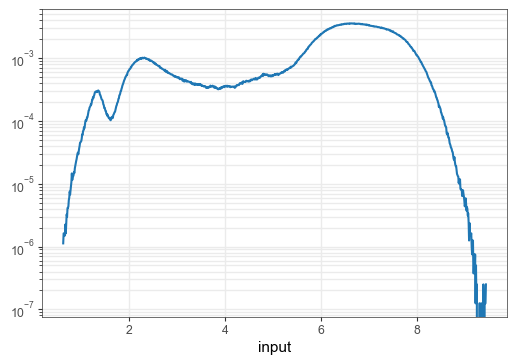

In [ ]:
# * Plot a distribution
h = result['grand_distribution']['E.input'][0][0]
bs = result['grand_distribution']['E.input'][1][0]
h = h / jnp.sum(h)  # normalize the histogram

# * Plot the distribution
plt.figure(figsize=(6, 4))
plt.semilogy(bs[20:], h[20:])
plt.xlabel('input')

(0.0, 100.0)

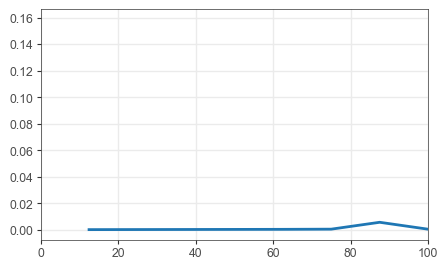

In [ ]:
# * Plot the spike spectrum

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111)
spectrum = result['spike_spectrum']['E.spike'][0]
freqs = jnp.fft.fftfreq(spectrum.shape[0], bp.share["dt"]/1000)
idxs = freqs > 0
ax.plot(freqs[idxs], spectrum[idxs], lw=2)
ax.set_xlim(0, 100)
